# Policy Gradient

# Smart Ad Placement Simulation

## Problem Idea

* Consider a mobile gaming company. After each level completion, the system must decide:
    * Show Short Ad
    * Show Long Ad
    * Show No Ad
* Each choice has consequences:
    * Short Ad generates small revenue but slightly reduces engagement.
    * Long Ad generates high revenue but significantly reduces engagement.
    * No Ad preserves engagement but produces no immediate revenue.

* The player’s engagement score determines whether they continue playing.
    * If engagement drops to zero:
        * The player quits.
        * The episode ends.
        * Future revenue is lost.
* Thus, decisions are sequential and affect long-term rewards.

* The objective of this lab is to design and implement a reinforcement learning agent that learns an optimal advertisement placement policy in a simulated mobile gaming environment. Therefore, the decision-making system must carefully balance two competing goals:
    1. Maximizing short-term revenue generated by advertisements.
    2. Maintaining long-term player engagement so that players continue playing the game.
* The goal of the reinforcement learning agent is therefore to learn a policy that maximizes the expected cumulative reward over time, taking into account both immediate and future consequences of each decision.

In this lab we will implement the REINFORCE Policy Gradient algorithm.

Unlike value-based reinforcement learning methods (such as Q-learning), policy gradient methods directly learn a policy that maps states to actions.

Instead of estimating value functions and then deriving a policy from them, policy gradient methods learn the policy parameters by maximizing expected cumulative rewards.

The core idea is:

1. The agent interacts with the environment.
2. The agent collects trajectories (state → action → reward).
3. The algorithm computes returns for each step.
4. The policy is updated to increase the probability of actions that produced high returns.

In this lab we simulate a mobile gaming advertisement placement system, where the reinforcement learning agent must decide what type of advertisement to show after each game level.

The agent must balance:

* Immediate advertisement revenue
* Long-term player engagement

#### Import Libraries and Env Setup

In [1]:
# Numerical operations
import numpy as np

# TensorFlow will be used to build the neural network (policy network)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Matplotlib for visualizing training performance
import matplotlib.pyplot as plt

### Understanding the Environment

Before implementing the learning algorithm, we must first define the environment in which the agent operates. In this simulation, the environment represents a simplified mobile game session.
The environment keeps track of two important variables:

1. Player Engagement Level

This represents how interested the player currently is in continuing the game.
The engagement score ranges from 0 to 10.

* If engagement reaches 0, the player quits the game.
* This terminates the episode.

2. Game Level

The player progresses through levels of the game.
Each level represents a decision point where the system can choose what advertisement strategy to apply.

#### Possible Actions
The reinforcement learning agent can choose between three actions:
| Action | Description              |
| ------ | ------------------------ |
| 0      | Show Short Advertisement |
| 1      | Show Long Advertisement  |
| 2      | Show No Advertisement    |

Each action affects both: Immediate revenue and Player engagement

#### Reward Structure

| Action   | Reward | Engagement Impact         |
| -------- | ------ | ------------------------- |
| Short Ad | +1     | Small engagement decrease |
| Long Ad  | +4     | Large engagement decrease |
| No Ad    | 0      | Engagement increases      |

Thus, the agent must learn to balance short-term reward vs long-term engagement.

### Define the Environment

In [2]:
class AdPlacementEnv:
    
    """
    This class simulates the mobile game advertisement environment.
    
    The environment tracks:
        - player engagement level
        - current game level
    
    The agent chooses an action (ad type) and receives a reward.
    
    The environment then updates the engagement score accordingly.
    
    If engagement drops to zero, the player quits and the episode ends.
    """
    
    def __init__(self):
        
        # Maximum number of levels a player can play in one episode
        self.max_levels = 20
        
        # Reset the environment to initial state
        self.reset()
        
    
    def reset(self):
        """
        Reset environment to starting state.
        
        This function is called at the beginning of every episode.
        """
        
        # Player starts at level 1
        self.level = 1
        
        # Initial engagement score
        self.engagement = 8.0
        
        # Return initial state
        return self._get_state()
    
    
    def _get_state(self):
        """
        Construct the state representation.
        
        The state contains:
        [engagement_level, current_level]
        """
        
        return np.array([self.engagement, self.level], dtype=np.float32)
    
    
    def step(self, action):
        """
        Execute the selected action in the environment.
        
        Parameters
        ----------
        action : int
            The action chosen by the agent
        
        Returns
        -------
        next_state
        reward
        done
        """
        
        done = False
        reward = 0
        
        # Action Effects
        
        # Short Advertisement
        if action == 0:
            reward = 1
            self.engagement -= 0.5
        
        # Long Advertisement
        elif action == 1:
            reward = 4
            self.engagement -= 1.0
        
        # No Advertisement
        else:
            reward = 0
            self.engagement += 1.0
        
        # Keep engagement between valid bounds
        self.engagement = np.clip(self.engagement, 0, 10)
        
        # Move to next level
        self.level += 1
        
        # Episode termination condition
        if self.engagement <= 0 or self.level > self.max_levels:
            done = True
        
        return self._get_state(), reward, done

### Policy Network Explanation

The policy network is a neural network that represents the agent’s policy. It takes the current state as input and produces a probability distribution over actions.

Mathematically:  𝜋𝜃(𝑎∣𝑠)  represents the probability that the policy selects action a given state s.

The network architecture used here is simple:

State → Dense Layer → ReLU → Dense Layer → Softmax

Softmax ensures that:
* All outputs are probabilities
* Probabilities sum to 1

This allows the agent to sample actions stochastically. Stochastic policies are essential for exploration in policy gradient methods.

### Define Policy Network (TensorFlow)

In [3]:
def create_policy_network(state_dim, action_dim):
    
    """
    Creates the policy neural network.
    
    Input:
        state_dim : dimension of state vector
        action_dim : number of possible actions
        
    Output:
        TensorFlow model that outputs action probabilities
    """
    
    model = keras.Sequential([
        
        # First fully connected layer
        layers.Dense(
            32,
            activation="relu",
            input_shape=(state_dim,)
        ),
        
        # Output layer producing action logits
        layers.Dense(action_dim, activation="softmax")
        
    ])
    
    return model

### Understanding the REINFORCE Update

The REINFORCE algorithm works using Monte Carlo policy gradients.

The key idea is:
1. Run a full episode.
2. Collect rewards.
3. Compute discounted returns.

Interpretation:
* If return is high → increase probability of that action
* If return is low → decrease probability

### Final Training Code

In [4]:
# Create environment
env = AdPlacementEnv()

# Create policy network
policy = create_policy_network(2, 3)

# Optimizer
optimizer = keras.optimizers.Adam(learning_rate=0.01)

gamma = 0.99
num_episodes = 500

episode_rewards = []

action_counts = [0,0,0]

for episode in range(num_episodes):
    
    state = env.reset()
    
    # Store episode data
    states = []
    actions = []
    rewards = []
    
    done = False
    
    # -----------------------------
    # Run one full episode
    # -----------------------------
    
    while not done:
        
        state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
        
        # Predict action probabilities
        action_probs = policy(state_tensor)
        action_probs = tf.squeeze(action_probs)
        
        # Sample action from probability distribution
        action = np.random.choice(3, p=action_probs.numpy())
        
        # Store state and action
        states.append(state)
        actions.append(action)
        
        # Execute action
        next_state, reward, done = env.step(action)

        action_counts[action] += 1
        
        rewards.append(reward)
        state = next_state
    
    
    # Compute discounted returns
    
    returns = []
    G = 0
    
    for r in reversed(rewards):
        G = r + gamma * G
        returns.insert(0, G)
    
    returns = np.array(returns)
    
    # Normalize returns (reduces training variance)
    returns = (returns - returns.mean()) / (returns.std() + 1e-8)
    
    
    # Policy Gradient Update
    
    with tf.GradientTape() as tape:
        
        loss = 0
        
        # Loop over episode steps
        for state, action, G in zip(states, actions, returns):
            
            state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
            
            # Forward pass through policy network
            action_probs = policy(state_tensor)
            action_probs = tf.squeeze(action_probs)
            
            # Compute log probability of the action taken
            log_prob = tf.math.log(action_probs[action])
            
            # Policy gradient loss
            loss += -log_prob * G
    
    
    # Compute gradients of loss w.r.t policy parameters
    gradients = tape.gradient(loss, policy.trainable_variables)
    
    # Apply gradient update
    optimizer.apply_gradients(zip(gradients, policy.trainable_variables))
    
    
    # Store episode reward for plotting
    episode_rewards.append(sum(rewards))

c:\github\samratkar.github.io\_posts\concepts\drl\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


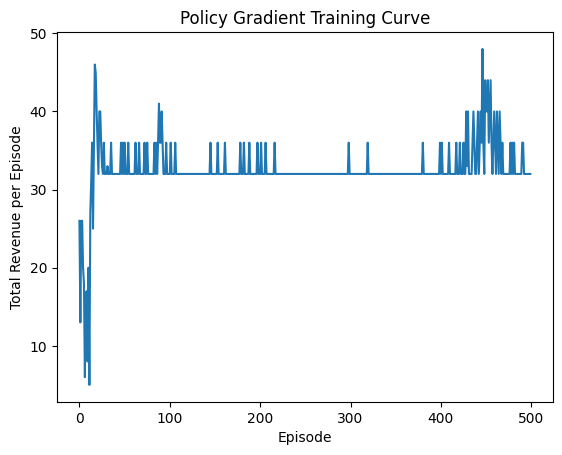

In [5]:
# Plot Training Results

plt.plot(episode_rewards)

plt.xlabel("Episode")
plt.ylabel("Total Revenue per Episode")
plt.title("Policy Gradient Training Curve")

plt.show()

As training progresses:

* Early episodes show unstable behavior because the policy is random.
* Over time the policy improves and learns to balance revenue and engagement.
* The reward curve gradually increases and stabilizes.

This demonstrates how policy gradient methods directly optimize decision policies through interaction with the environment.

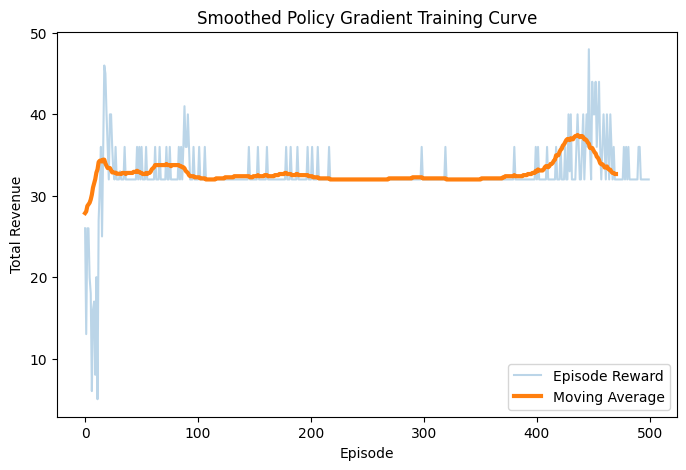

In [6]:
window = 30

moving_avg = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode="valid"
)

plt.figure(figsize=(8,5))

plt.plot(episode_rewards, alpha=0.3, label="Episode Reward")
plt.plot(moving_avg, linewidth=3, label="Moving Average")

plt.xlabel("Episode")
plt.ylabel("Total Revenue")
plt.title("Smoothed Policy Gradient Training Curve")

plt.legend()
plt.show()

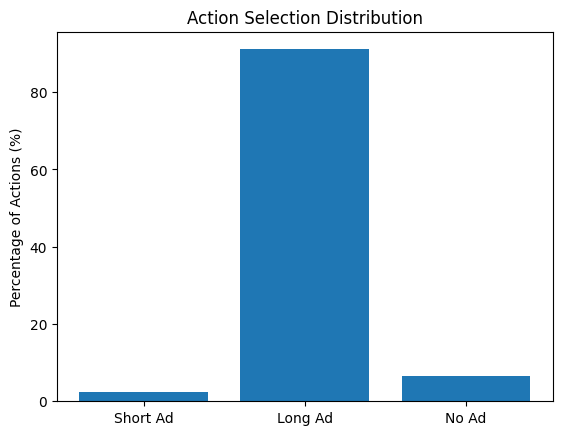

In [7]:
# Action Distribution Over Time
labels = ["Short Ad","Long Ad","No Ad"]

total_actions = sum(action_counts)

action_percent = [c / total_actions * 100 for c in action_counts]

plt.bar(labels, action_percent)

plt.ylabel("Percentage of Actions (%)")
plt.title("Action Selection Distribution")

plt.show()

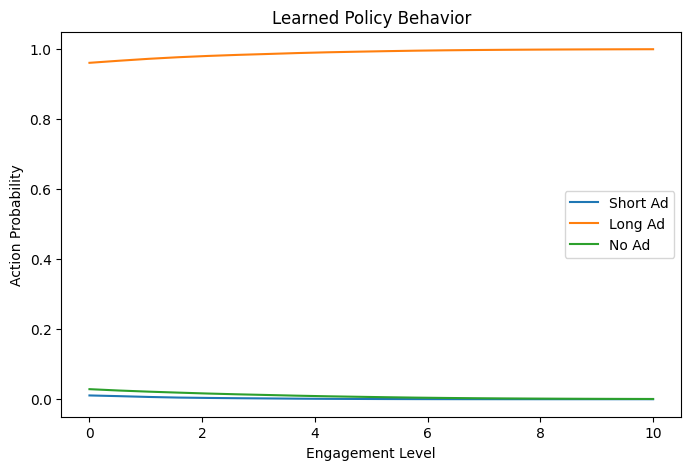

In [8]:

# Visualize Policy Behavior for Different States
engagement_levels = np.linspace(0,10,20)

short_probs = []
long_probs = []
noad_probs = []

for e in engagement_levels:
    
    state = tf.convert_to_tensor([[e,5]], dtype=tf.float32)
    probs = policy(state).numpy()[0]
    
    short_probs.append(probs[0])
    long_probs.append(probs[1])
    noad_probs.append(probs[2])

plt.figure(figsize=(8,5))

plt.plot(engagement_levels, short_probs,label="Short Ad")
plt.plot(engagement_levels, long_probs,label="Long Ad")
plt.plot(engagement_levels, noad_probs,label="No Ad")

plt.xlabel("Engagement Level")
plt.ylabel("Action Probability")
plt.title("Learned Policy Behavior")

plt.legend()
plt.show()

* If engagement is low  → No Ad (protect player retention)
* If engagement medium  → Mixed decisions
* If engagement high    → Long Ad (maximize revenue)

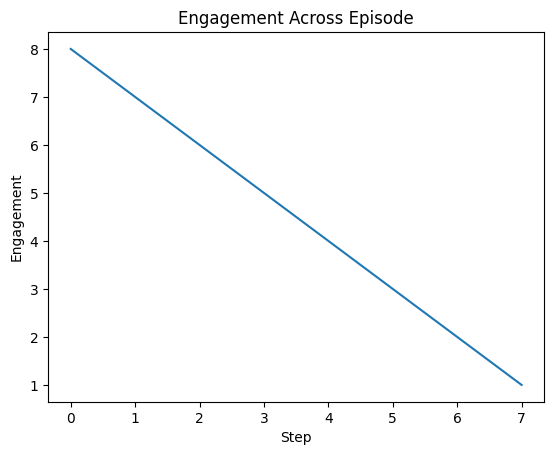

In [9]:
#Visualize One Full Episode
state = env.reset()

engagement_history = []
reward_history = []

done = False

while not done:
    
    state_tensor = tf.convert_to_tensor([state], dtype=tf.float32)
    probs = policy(state_tensor)[0].numpy()
    
    action = np.argmax(probs)
    
    next_state, reward, done = env.step(action)
    
    engagement_history.append(state[0])
    reward_history.append(reward)
    
    state = next_state

plt.plot(engagement_history)
plt.title("Engagement Across Episode")
plt.xlabel("Step")
plt.ylabel("Engagement")
plt.show()